# Solution 30.1: Implementing state-based cooperativity


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def rhs_razumova(t, y, k_u_on, k_u_off, f_0, f_prime_0, h, h_prime, g, u, v, w):
    D, A1, A2 = y
    R_off = 1.0 - (D + A1 + A2)

    lam_on = D + A1 + A2
    lam_A2 = A2

    k_w_on = k_u_on * (1 + lam_on * (u - 1)) ** 2
    k_w_off = k_u_off * (u - lam_on * (u - 1)) ** 2

    k_on = k_w_on * (1 + lam_A2 * (np.exp(w - 1) - 1)) ** 2
    k_off = k_w_off * (1 + lam_A2 * (np.exp(-(w - 1)) - 1)) ** 2

    f = f_0 * (1 + lam_A2 * (np.exp(v - 1) - 1)) ** 2
    f_prime = f_prime_0 * (1 + lam_A2 * (np.exp(-(v - 1)) - 1)) ** 2

    dD_dt = k_on * R_off + f_prime * A1 + g * A2 - (k_off + f) * D
    dA1_dt = f * D + h_prime * A2 - (f_prime + h) * A1
    dA2_dt = h * A1 - (h_prime + g) * A2

    return [dD_dt, dA1_dt, dA2_dt]

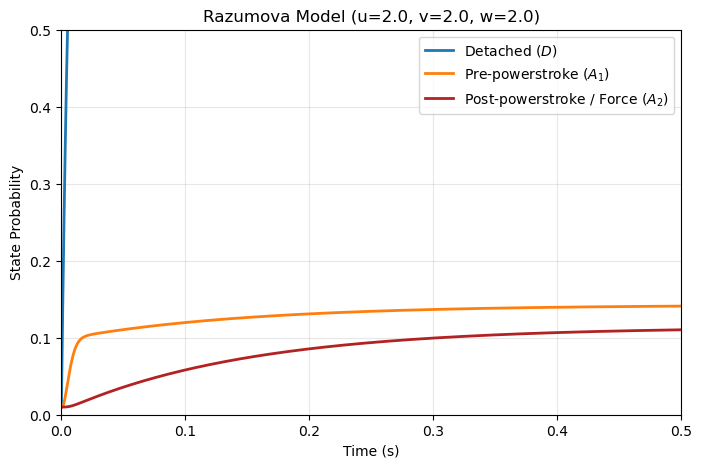

In [ ]:
# Base kinetic parameters
k_u_on, k_u_off = 120.0, 50.0
f_0, f_prime_0 = 50.0, 400.0
h_rate, h_prime, g_rate = 8.0, 6.0, 4.0

u, v, w = 2.0, 2.0, 2.0  # Positive cooperativity

params = (k_u_on, k_u_off, f_0, f_prime_0, h_rate, h_prime, g_rate, u, v, w)
y0 = [0.01, 0.01, 0.01]
t_span = (0, 0.5)

sol = solve_ivp(rhs_razumova, t_span, y0, args=params, max_step=0.001)

plt.figure(figsize=(8, 5))
plt.plot(sol.t, sol.y[0], label="Detached ($D$)", linewidth=2)
plt.plot(sol.t, sol.y[1], label="Pre-powerstroke ($A_1$)", linewidth=2)
plt.plot(
    sol.t,
    sol.y[2],
    label="Post-powerstroke / Force ($A_2$)",
    color="firebrick",
    linewidth=2,
)

plt.xlabel("Time (s)")
plt.ylabel("State Probability")
plt.title(f"Razumova Model (u={u}, v={v}, w={w})")
plt.legend()
plt.xlim(0, 0.5)
plt.ylim(0, 0.5)
plt.grid(alpha=0.3)
plt.show()